In [25]:
from google.colab import files
uploaded = files.upload()

Saving brain_tumor_dataset.zip to brain_tumor_dataset.zip


In [26]:
!unzip brain_tumor_dataset.zip

Archive:  brain_tumor_dataset.zip
   creating: brain_tumor_dataset/
   creating: brain_tumor_dataset/no/
  inflating: brain_tumor_dataset/no/1 no.jpeg  
  inflating: brain_tumor_dataset/no/10 no.jpg  
  inflating: brain_tumor_dataset/no/11 no.jpg  
  inflating: brain_tumor_dataset/no/12 no.jpg  
  inflating: brain_tumor_dataset/no/13 no.jpg  
  inflating: brain_tumor_dataset/no/14 no.jpg  
  inflating: brain_tumor_dataset/no/15 no.jpg  
  inflating: brain_tumor_dataset/no/17 no.jpg  
  inflating: brain_tumor_dataset/no/18 no.jpg  
  inflating: brain_tumor_dataset/no/19 no.jpg  
  inflating: brain_tumor_dataset/no/2 no.jpeg  
  inflating: brain_tumor_dataset/no/20 no.jpg  
  inflating: brain_tumor_dataset/no/21 no.jpg  
  inflating: brain_tumor_dataset/no/22 no.jpg  
  inflating: brain_tumor_dataset/no/23 no.jpg  
  inflating: brain_tumor_dataset/no/24 no.jpg  
  inflating: brain_tumor_dataset/no/25 no.jpg  
  inflating: brain_tumor_dataset/no/26 no.jpg  
  inflating: brain_tumor_datase

In [27]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [28]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    "brain_tumor_dataset",
    target_size=(128,128),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

val_data = datagen.flow_from_directory(
    "brain_tumor_dataset",
    target_size=(128,128),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [30]:
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(1,activation='sigmoid'))

In [31]:
model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

In [32]:
history = model.fit(
train_data,
epochs=10,
validation_data=val_data
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 998ms/step - accuracy: 0.6305 - loss: 0.8916 - val_accuracy: 0.7400 - val_loss: 0.5953
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7783 - loss: 0.5365 - val_accuracy: 0.7600 - val_loss: 0.6810
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 944ms/step - accuracy: 0.7833 - loss: 0.5311 - val_accuracy: 0.7400 - val_loss: 0.5665
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8128 - loss: 0.4693 - val_accuracy: 0.7400 - val_loss: 0.5284
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 916ms/step - accuracy: 0.7882 - loss: 0.4775 - val_accuracy: 0.7600 - val_loss: 0.5331
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8177 - loss: 0.4549 - val_accuracy: 0.7600 - val_loss: 0.6045
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8522 - loss: 0.4196 - val_accuracy: 0.7600 - val_loss: 0.5009
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8571 - loss: 0.3931 - val_accuracy: 0.7800 - val_loss: 0.5301
Epoch 

In [33]:
loss, acc = model.evaluate(val_data)

print("Validation Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.8000 - loss: 0.5135
Validation Accuracy: 0.800000011920929


In [34]:
img, label = next(val_data)

prediction = model.predict(img)

print("Predicted:", prediction[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step
Predicted: [0.76589656]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

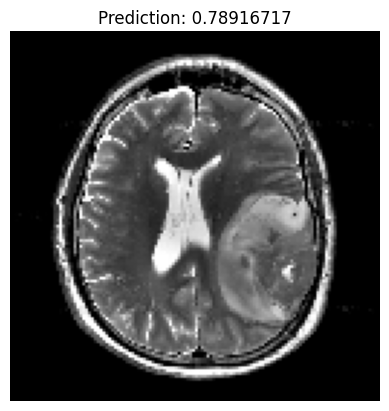

In [35]:
img, label = next(val_data)

prediction = model.predict(img)

plt.imshow(img[0])
plt.title("Prediction: " + str(prediction[0][0]))
plt.axis("off")